타이타닉 생존자 예측을 위한 EDA
**생존자 데이터 분석에서 나이,성별 중요함**


## 라이브러리 호출 및 전처리

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 한국어폰트(윈도우)
plt.rcParams["font.family"] = "Malgun Gothic"
# 맥 => AppleGothic

plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 타이타닉 데이터 불러오기 (pandas)
import seaborn as sns
df=sns.load_dataset("titanic")
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# 나이채우기
# 경고수정하기 inplace
# df["age"] == select age from df
df["age"]=df["age"].fillna(df["age"].mean())
df["embarked"].fillna(df["embarked"].mode()[0])
# # df.info()

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

생존자 현황

In [11]:
# 생존자 수
survived_count = df["survived"].value_counts()

# 생존자 비율
survived_rate = df["survived"].mean()
print(f"생존자:{survived_count[1]}명")
print(f"사망자:{survived_count[0]}명")
print(f"생존율:{survived_rate:.2%}")

생존자:342명
사망자:549명
생존율:38.38%


## 2. 승객 등급에 따른 생존율
    2-1.등급별 생존자 수
    2-2.등급별 생존율
    2-3.등급별 성별 교차표

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/opt/miniconda3/envs/aip39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/aip39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/miniconda3/envs/aip39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s

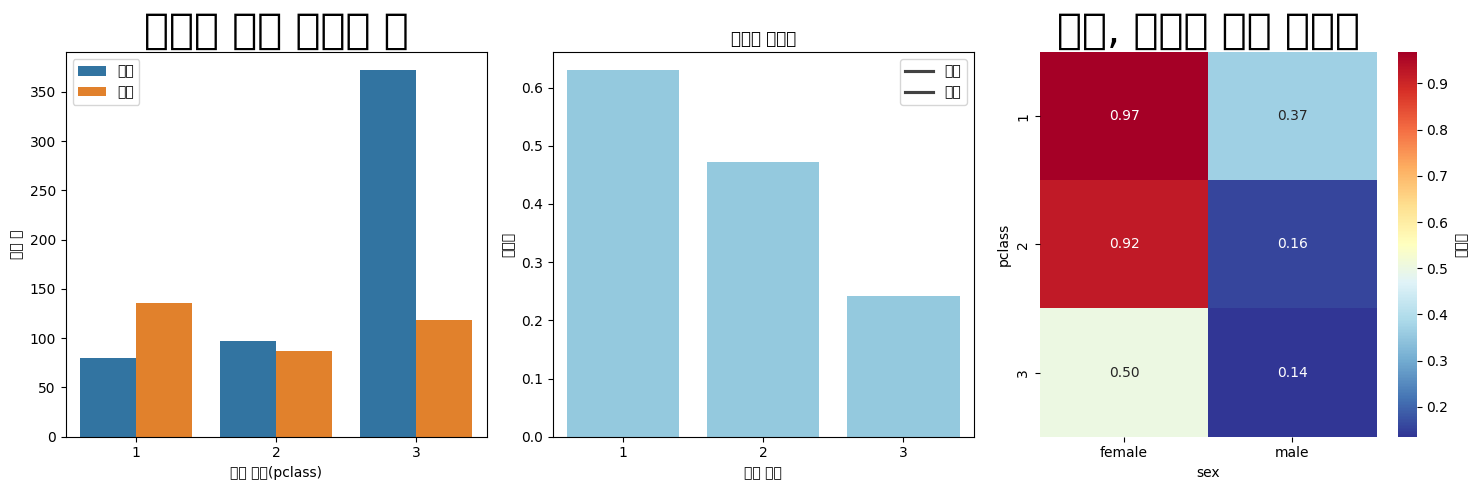

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3,figsize=(15,5))

# 2-1. 등급별 생존자 수 (독립변인 => pclass)
# sns.countplot(data=df, x="sex", hue="survived", ax=axes[0])
sns.countplot(data=df, x="pclass", hue="survived", ax=axes[0])
axes[0].set_title("등급에 따른 생존자 수", fontsize=30)
axes[0].set_xlabel("승객 등급(pclass)")
axes[0].set_ylabel("승객 수")
axes[0].legend(labels=["사망","생존"])

# 2-2. 등급별 생존율 
pclass_survived = df.groupby("pclass")["survived"].mean().reset_index()
sns.barplot(data=pclass_survived, 
            x="pclass", 
            y="survived", 
            ax=axes[1], 
            color="skyblue")
axes[1].set_title("등급별 생존율")
axes[1].set_xlabel("승객 등급")
axes[1].set_ylabel("생존율")
axes[1].legend(labels=["사망", "생존"])

# 2-3. 히트맵 : 등급 + 성별 생존율
# aggfunc : 집계함수(기준)
# annot=True : 각 셀 안에 실제 숫자 값을 표시
cross_tab= pd.crosstab(df["pclass"],df["sex"],values=df["survived"], aggfunc="mean")
sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap="RdYlBu_r", cbar_kws={"label":"생존율"}, ax=axes[2])
axes[2].set_title("등급, 성별에 따른 생존율", fontsize=30)

plt.tight_layout()
plt.show();

In [27]:
pd.crosstab(df["pclass"],df["sex"],values=df["survived"], aggfunc="mean")

sex,female,male
pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [35]:
df["age"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

## 3. 나이에 따른 생존율 분석
    3-1. 성별과 나이 boxplots으로나타내기
    3-2. 전체 나이 분포
    3-3. 그룹별
    3-4. 생존 여부에 따른 나이 분포

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/wp/5f547wzn5rg3jym3dn9l9v640000gn/T/ipykernel_66145/2125286041.py:54: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wp/5f547wzn5rg3jym3dn9l9v640000gn/T/ipykernel_66145/2125286041.py:54: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun 

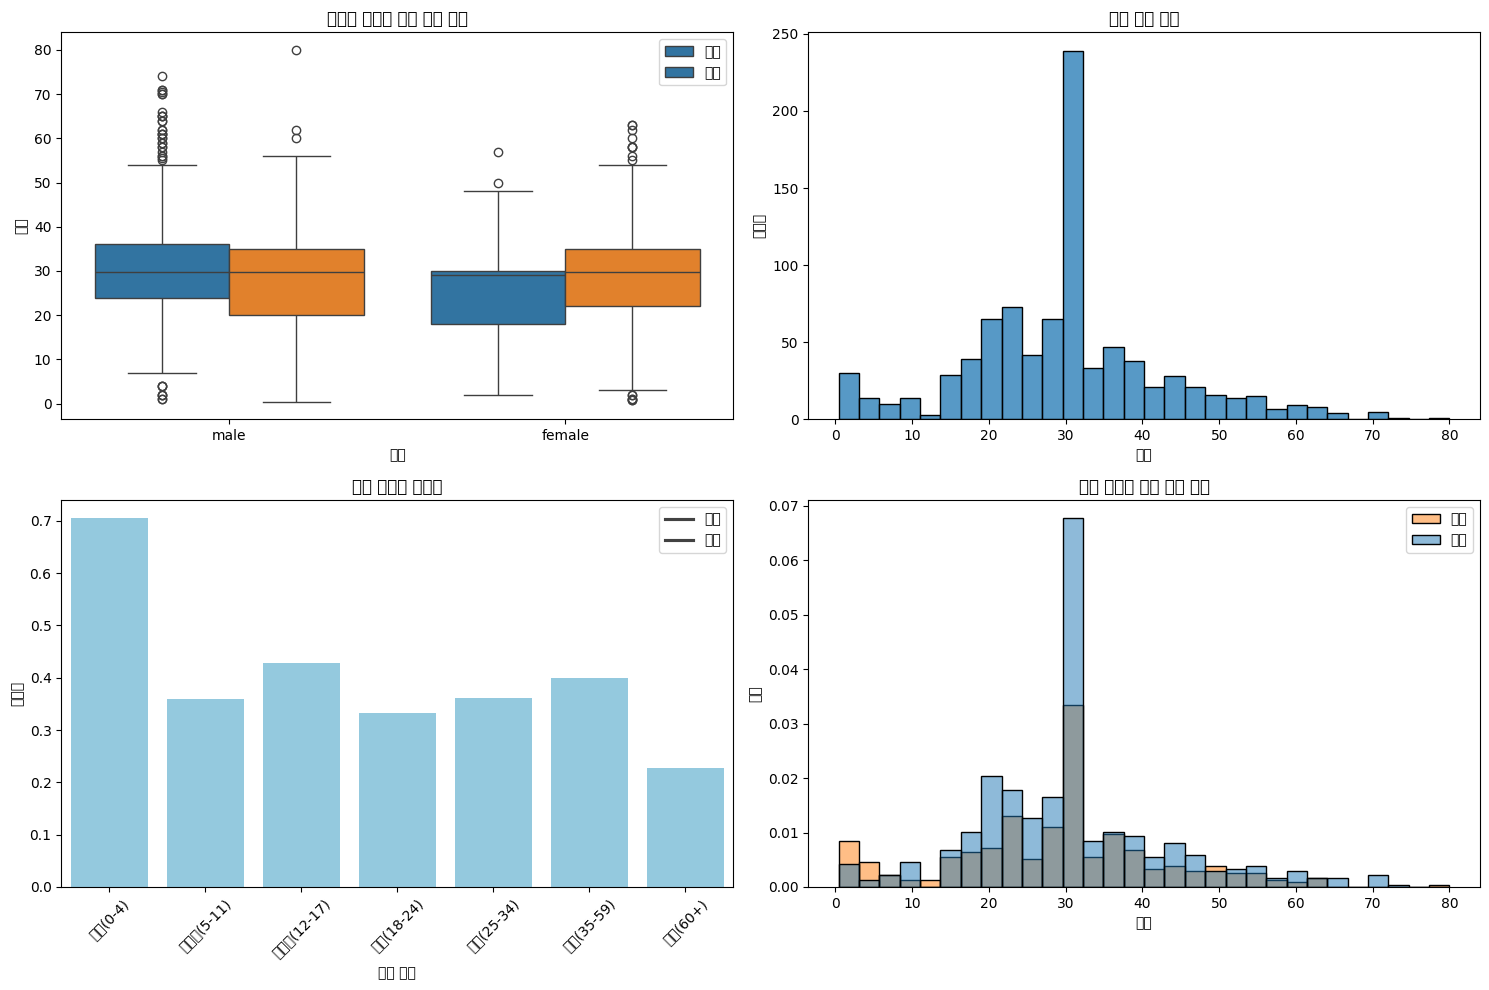

In [14]:
import matplotlib.pyplot as plt
# 그래프 4개
fig, axes = plt.subplots(2,2,figsize=(15,10))

# 3-1. 성별과 나이(boxplot)
sns.boxplot(data=df, x="sex", y="age", hue="survived", ax=axes[0, 0])
axes[0, 0].set_title("성별과 나이에 따른 생존 현황")
axes[0, 0].set_xlabel("성별")
axes[0, 0].set_ylabel("나이")
axes[0, 0].legend(labels=["사망", "생존"])


# 3-2. 전체 나이 분포(histplot)
sns.histplot(data=df, x="age", ax=axes[0, 1])
axes[0, 1].set_title("전체 승객 나이")
axes[0, 1].set_xlabel("나이")
axes[0, 1].set_ylabel("인원수")

# 3-3. 그룹별
# 유아 (0-4) 어린이(5-11) 청소년(12-17) 성인(18-24) 청년(25-34) 중년(35-59) 노인(60+)
# bins = [0,5,12,18,25,35,60,np.inf]
# pd.cut(df["age"], bins)
bins = [0, 5, 12, 18, 25, 35, 60, np.inf]
labels = [
    "유아(0-4)",
    "어린이(5-11)",
    "청소년(12-17)",
    "청년(18-24)",
    "성인(25-34)",
    "중년(35-59)",
    "노인(60+)",
]
df["age_group"] = pd.cut(df["age"], bins, labels=labels)

age_group_survived = (
    df.groupby("age_group", observed=True)["survived"].mean().reset_index()
)
sns.barplot(
    data=age_group_survived, x="age_group", y="survived", ax=axes[1, 0], color="skyblue"
)
axes[1, 0].set_title("나이 그룹별 생존율")
axes[1, 0].set_xlabel("나이 그룹")
axes[1, 0].set_ylabel("생존율")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(labels=["사망", "생존"])

# 3-4. 생존 여부에 따른 나이 분포
sns.histplot(data=df, x="age", hue="survived", stat="density", ax=axes[1, 1])
axes[1, 1].set_title("생존 여부에 따른 나이 분포")
axes[1, 1].set_xlabel("나이")
axes[1, 1].set_ylabel("밀도")
axes[1, 1].legend(labels=["사망", "생존"])

plt.tight_layout()
plt.show()